In [ ]:
"""
================================================================================
TITLE         : NLP Assignment 1 | 
GROUP NUMBER  : 
GROUP MEMBERS :
S.No.   BITS_ID           NAME--------------------------------------------------
1.      2024ac05382       HAREESH KUMAR K
2.      2024ac05361       RAHUL CHANDRAN
3.                        JAPNEET SINGH
-------------------------------------------------------------
ASSIGNMENT OVERVIEW: 
================================================================================
"""

'\n================================================================================\nTITLE         : NLP Assignment 1 | \nGROUP NUMBER  : \nGROUP MEMBERS :\nS.No.   BITS_ID           NAME--------------------------------------------------\n1.      2024ac05382       HAREESH KUMAR K\n2.      2024ac05361       RAHUL CHANDRAN\n3.             JAPNEET SINGH\n-------------------------------------------------------------\nASSIGNMENT OVERVIEW: \n================================================================================\n'

## Cell 1 - Download and perform EDA on NLTK Brown Dataset

In [26]:
# Configure Necessary Imports in accordance to the requirements of the assignment
import nltk
from collections import Counter


In [27]:
# Download the brown corpus if not already downloaded
nltk.download('brown')
# Verify the import and availability of the brown corpus
from nltk.corpus import brown
print("Brown Corpus Categories:", brown.categories())
# Load the tagged sentences from the brown corpus for training and testing
train_data = brown.tagged_sents(categories="government")
test_data = brown.tagged_sents(categories="humor")
# Extract some metrics from the training data
sent_train_data_count = len(train_data)
token_train_data_count = sum(len(sent) for sent in train_data)
print("Number of training sentences:", sent_train_data_count)
print("Number of training tokens:", token_train_data_count)
print("First training sentence:", train_data[0])
print("Token count ", token_train_data_count)

# Extract the tag counts and vocabulary from the training data
tag_counts = Counter()
word_counts = Counter()
vocab = set()

for sent in train_data:
    for word, tag in sent:
        tag_counts[tag] += 1
        word_counts[word.lower()] += 1
        vocab.add(word.lower())

print("Tag counts:", tag_counts)
print("Word frequencies:", word_counts)
print("Vocabulary size:", len(vocab))
print("Vocabulary:", sorted(vocab))



[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


Brown Corpus Categories: ['adventure', 'belles_lettres', 'editorial', 'fiction', 'government', 'hobbies', 'humor', 'learned', 'lore', 'mystery', 'news', 'religion', 'reviews', 'romance', 'science_fiction']
Number of training sentences: 3032
Number of training tokens: 70117
First training sentence: [('The', 'AT'), ('Office', 'NN-TL'), ('of', 'IN-TL'), ('Business', 'NN-TL'), ('Economics', 'NN-TL'), ('(', '('), ('OBE', 'NP'), (')', ')'), ('of', 'IN'), ('the', 'AT'), ('U.S.', 'NP-TL'), ('Department', 'NN-TL'), ('of', 'IN-TL'), ('Commerce', 'NN-TL'), ('provides', 'VBZ'), ('basic', 'JJ'), ('measures', 'NNS'), ('of', 'IN'), ('the', 'AT'), ('national', 'JJ'), ('economy', 'NN'), ('and', 'CC'), ('current', 'JJ'), ('analysis', 'NN'), ('of', 'IN'), ('short-run', 'NN'), ('changes', 'NNS'), ('in', 'IN'), ('the', 'AT'), ('economic', 'JJ'), ('situation', 'NN'), ('and', 'CC'), ('business', 'NN'), ('outlook', 'NN'), ('.', '.')]
Token count  70117
Tag counts: Counter({'NN': 9877, 'IN': 8596, 'AT': 5716, 

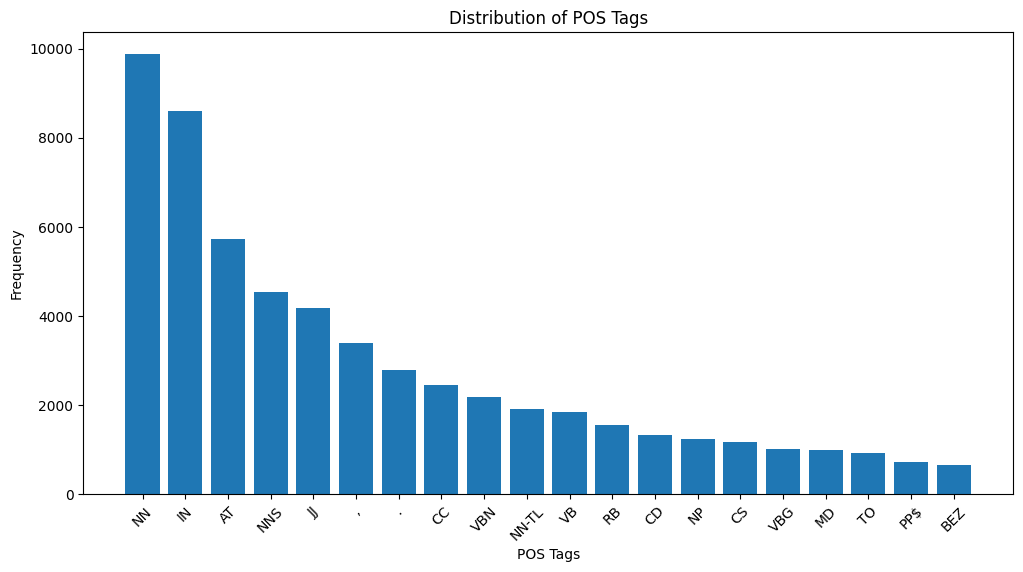

In [28]:
#plot POS tag distribution of the top 20 most common tags
top_tags = tag_counts.most_common(20)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar([tag for tag, freq in top_tags], [freq for tag, freq in top_tags])
plt.xlabel("POS Tags")
plt.ylabel("Frequency")
plt.title("Distribution of POS Tags")
plt.xticks(rotation=45)
plt.show()

In [30]:
# Get Frequency of words less than or equal to 2
low_freq_words = {word: freq for word, freq in word_counts.items() if freq <= 2}
print("Words with frequency <= 2:", low_freq_words)
# replace low frequency words in the training data with <UNK>
train_data_unk = []

for sent in train_data:
    new_sent = [(word if word.lower() not in low_freq_words else "<UNK>", tag) for word, tag in sent]
    train_data_unk.append(new_sent)
# Pad the sentences in the training data with <START> and <END> tokens
train_data_padded = []
for sent in train_data_unk:
    new_sent = [("<START>", "<START>")] + sent + [("<END>", "<END>")]
    train_data_padded.append(new_sent)
print("Sample padded sentence:", train_data_padded[0])


Words with frequency <= 2: {'obe': 1, 'short-run': 2, 'develops': 1, 'analyzes': 1, 'indicators': 1, 'presenting': 2, 'economists': 2, 'periodical': 2, 'statistical': 2, 'supplements': 1, 'dealt': 2, 'managers': 1, 'enterprises': 2, 'know-how': 1, 'cosponsors': 1, "sba's": 2, 'personalized': 1, 'one-day': 1, 'streamlined': 1, 'chambers': 2, 'semi-processed': 1, 'adaptable': 1, 'exploitation': 1, 'arise': 2, 'undertook': 1, 'urgently': 2, 'locate': 2, 'competitively': 1, 'reviewing': 1, 'identifying': 2, 'publicized': 1, 'releases': 1, 'flyers': 1, 'principally': 2, 'contacted': 1, '8-b-2': 1, 'authorizes': 1, 'voluntarily': 1, 'register': 1, 'avail': 1, "registrants'": 1, 'budgetary': 2, 'atlanta': 2, 'ga.': 2, 'mass.': 2, 'dallas': 2, 'tex.': 2, 'denver': 2, 'colo.': 2, 'detroit': 2, 'mich.': 2, 'mo.': 2, 'minneapolis': 2, 'minn.': 2, 'n.y.': 2, 'pa.': 2, 'va.': 2, 'san': 2, 'francisco': 2, 'seattle': 2, 'wash.': 2, 'topics': 2, 'selling': 1, 'lending': 2, 'pools': 1, 'wholesalers': 1

## Cell 7 - Model Architecture & Parameter Estimation

In [ ]:
# Loop through the training data set and extract the 
#   1. Tag -> Tag transition counts
#   2. Word -> Tag emission counts

unk_prob = 1e-6
transition_counts = Counter()
emission_counts = Counter()
for sent in train_data_padded:
    for i in range(1, len(sent)):
        prev_tag = sent[i-1][1]
        curr_tag = sent[i][1]
        transition_counts[(prev_tag, curr_tag)] += 1
        emission_counts[(sent[i][0].lower(), curr_tag)] += 1
        
print("Tag Transition Counts:", transition_counts)
print("Word-Tag Emission Counts:", emission_counts)

Tag Transition Counts: Counter({('NN', 'IN'): 3150, ('IN', 'AT'): 2887, ('AT', 'NN'): 2560, ('.', '<END>'): 2531, ('JJ', 'NN'): 1883, ('NNS', 'IN'): 1430, ('IN', 'NN'): 1430, ('NN', 'NN'): 1055, ('AT', 'JJ'): 1010, ('NN', ','): 997, ('JJ', 'NNS'): 991, ('NN', '.'): 938, ('VBN', 'IN'): 896, ('TO', 'VB'): 783, ('IN', 'JJ'): 775, ('NN', 'NNS'): 683, ('NN', 'CC'): 624, (',', 'CC'): 575, ('NNS', ','): 568, ('<START>', 'AT'): 558, ('NNS', '.'): 548, ('AT', 'NN-TL'): 521, ('IN', 'NNS'): 484, ('CC', 'NN'): 437, ('MD', 'BE'): 403, ('AT', 'NNS'): 401, ('VB', 'AT'): 397, ('IN', 'CD'): 384, ('BE', 'VBN'): 376, ('MD', 'VB'): 365, ('<START>', 'IN'): 364, ('NNS', 'CC'): 362, ('IN', 'PP$'): 349, (',', 'IN'): 342, ('IN', 'VBG'): 334, (',', 'AT'): 331, ('IN', 'DT'): 328, ('DT', 'NN'): 325, ('CS', 'AT'): 318, ('NN-TL', 'IN-TL'): 301, ('PP$', 'NN'): 292, ('IN', 'NP'): 288, ('NN-TL', 'NN-TL'): 286, ('JJ', 'IN'): 283, ('RB', 'IN'): 282, ('NN-TL', ','): 275, ('CD', 'NNS'): 266, ('VB', 'IN'): 261, ('NN', 'MD'

In [ ]:
# Convert the transition and emission counts to probabilities
# Assign a small probability to unseen words using the <UNK> token
transition_probs = {}
for (prev_tag, curr_tag), count in transition_counts.items():
    transition_probs[(prev_tag, curr_tag)] = count / sum(1 for (p, c) in transition_counts if p == prev_tag)

emission_probs = {}
for (word, tag), count in emission_counts.items():
    # For words marked with the <UNK> token, use the <UNK> token probability
    if word == "<UNK>":
        emission_probs[(word, tag)] = unk_prob
    else:
        emission_probs[(word, tag)] = count / sum(1 for (w, t) in emission_counts if t == tag)

print("Tag Transition Probabilities:", transition_probs)
print("Word-Tag Emission Probabilities:", emission_probs)